In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load and prepare dataset

In [4]:
MNIST_MEAN, MNIST_STD = 0.13, 0.31
NUM_CLASSES = 10
transform = T.Compose([T.ToTensor(), T.Normalize(MNIST_MEAN, MNIST_STD)])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

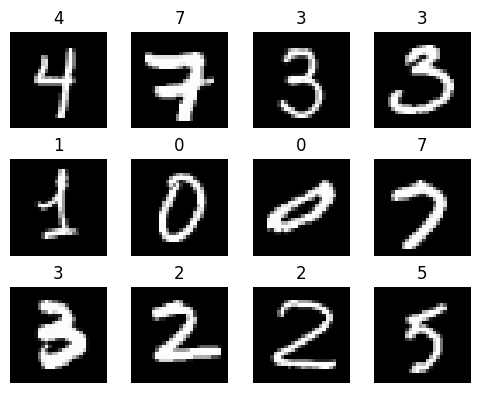

In [64]:
def show_images(images, labels, predictions=None, n_cols=4):
    n_rows = (len(images) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 4))
    axes = axes.flatten()

    for i in range(len(images)):
        axes[i].imshow(images[i].reshape(28, 28), cmap="gray")
        if predictions is not None:
            color = "green" if predictions[i] == labels[i] else "red"
            axes[i].set_title(
                f"True: {labels[i].item()}\nPred: {predictions[i].item()}", color=color
            )
        else:
            axes[i].set_title(labels[i].item())
        axes[i].axis("off")

    for i in range(len(images), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()


dataiter = iter(train_loader)
images, y = next(dataiter)

show_images(images[:12], y[:12])

## Traditional CNN

In [6]:
class TinyCnn(nn.Module):
    def __init__(self):
        super(TinyCnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.flatten(start_dim=1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
model = TinyCnn()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    progress_bar = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        postfix={"loss": 0.0},
        unit="batch",
    )

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        progress_bar = tqdm(
            test_loader,
            total=len(test_loader),
            desc=f"Validation Epoch {epoch + 1}/{num_epochs}",
            unit="batch",
        )
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Epoch 1/3: 100%|██████████| 40/40 [00:00<00:00, 43.77batch/s]


Validation Accuracy: 97.08%


Validation Epoch 2/3: 100%|██████████| 40/40 [00:00<00:00, 41.73batch/s]


Validation Accuracy: 98.13%


Validation Epoch 3/3: 100%|██████████| 40/40 [00:00<00:00, 45.41batch/s]

Validation Accuracy: 98.42%


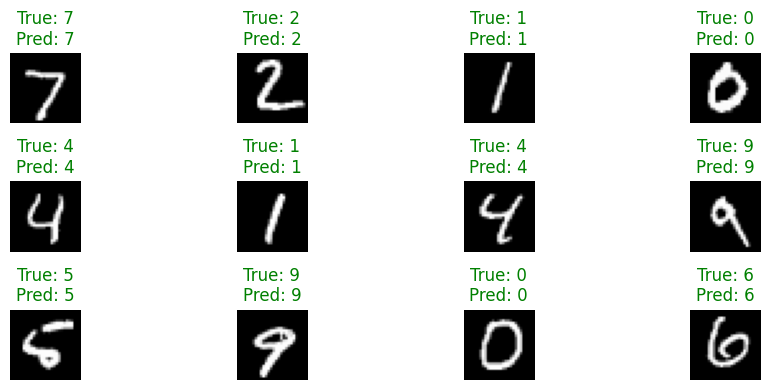

In [8]:
dataiter = iter(test_loader)
images, y = next(dataiter)
images, y = images.to(device), y.to(device)

with torch.no_grad():
    logits = model(images)
    _, preds = torch.max(logits, 1)

show_images(images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12])

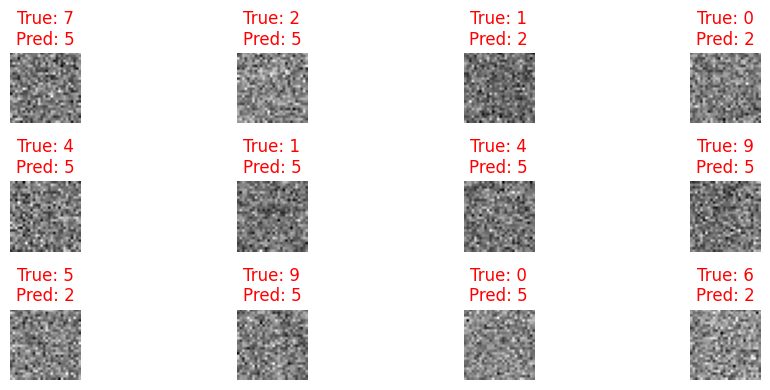

In [24]:
# add noise to images
noisy_images = torch.randn_like(images)

noisy_images, y = noisy_images.float().to(device), y.long().to(device)

with torch.no_grad():
    logits = model(noisy_images)
    _, preds = torch.max(logits, 1)

show_images(
    noisy_images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12]
)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

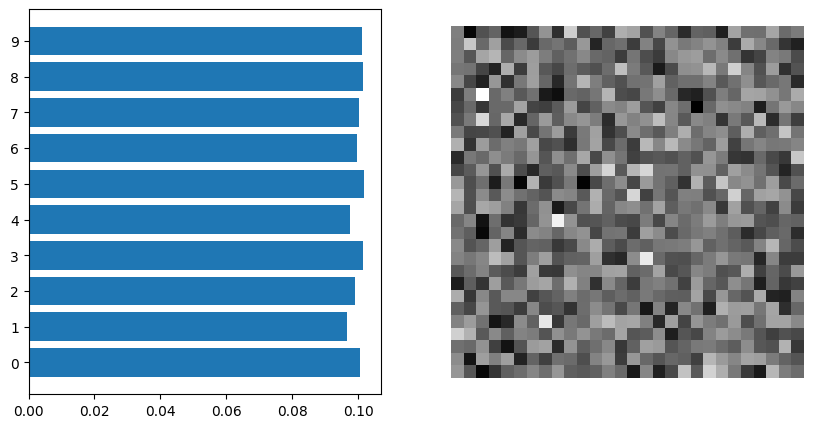

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
values = F.softmax(logits[0], dim=0)
axs[0].barh(range(len(values)), values)
axs[0].set_yticks(range(len(values)))

# plot image
axs[1].imshow(noisy_images[0].cpu().numpy().reshape(28, 28), cmap="gray")
axs[1].axis("off")

## Use EDL

In [45]:
def mse_dirichlet(alpha, y):
    S = torch.sum(alpha, dim=1, keepdim=True)
    p = alpha / S
    t1 = (y - p).pow(2).sum(-1)
    t2 = ((p * (1 - p)) / (S + 1)).sum(-1)
    return torch.mean(t1 + t2)


def kl_dirichlet(alpha, y):
    # suppress the evidence of non-target classes
    alpha = y + (1 - y) * alpha
    beta = torch.ones_like(alpha)

    # kl divergence based on https://statproofbook.github.io/P/dir-kl.html
    sum_alpha = alpha.sum(-1)
    sum_beta = beta.sum(-1)

    t1 = sum_alpha.lgamma() - sum_beta.lgamma()
    t2 = (alpha.lgamma() - beta.lgamma()).sum(-1)
    t3 = alpha - beta
    t4 = alpha.digamma() - sum_alpha.digamma().unsqueeze(-1)

    kl = t1 - t2 + (t3 * t4).sum(-1)
    return kl.mean()


def edl_loss(logits, labels, epoch, num_epochs):
    y = F.one_hot(labels, num_classes=NUM_CLASSES).float()

    evidence = F.softplus(logits)
    alpha = evidence + 1

    mse = mse_dirichlet(alpha, y)
    kl = kl_dirichlet(alpha, y)

    annealing_coef = min(1.0, epoch / num_epochs)

    return mse + annealing_coef * kl, mse.detach(), kl.detach()

In [ ]:
model = TinyCnn()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    progress_bar = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        postfix={"loss": 0.0},
        unit="batch",
    )

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss, _, _ = edl_loss(outputs, labels, epoch, num_epochs)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = 0
    total = 0
    uncertainty = 0.0
    with torch.no_grad():
        progress_bar = tqdm(
            test_loader,
            total=len(test_loader),
            desc=f"Validation Epoch {epoch + 1}/{num_epochs}",
            unit="batch",
        )
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            evidence = F.softplus(outputs)
            alpha = evidence + 1
            S = torch.sum(alpha, dim=1, keepdim=True)
            uncertainty += torch.sum(NUM_CLASSES / S).item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    print(f"Average Uncertainty: {uncertainty / total:.4f}")

Validation Epoch 1/5: 100%|██████████| 40/40 [00:00<00:00, 46.46batch/s]


Validation Accuracy: 94.61%
Average Uncertainty: 0.1494


Validation Epoch 2/5: 100%|██████████| 40/40 [00:00<00:00, 45.69batch/s]


Validation Accuracy: 96.33%
Average Uncertainty: 0.2502


Validation Epoch 3/5: 100%|██████████| 40/40 [00:00<00:00, 46.29batch/s]


Validation Accuracy: 97.27%
Average Uncertainty: 0.2086


Validation Epoch 4/5: 100%|██████████| 40/40 [00:00<00:00, 50.01batch/s]


Validation Accuracy: 97.92%
Average Uncertainty: 0.2066


Validation Epoch 5/5: 100%|██████████| 40/40 [00:00<00:00, 48.42batch/s]

Validation Accuracy: 97.67%
Average Uncertainty: 0.1998


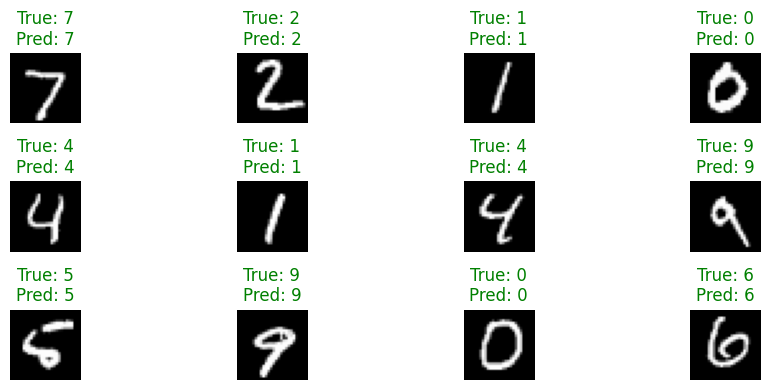

In [53]:
dataiter = iter(test_loader)
images, y = next(dataiter)
images, y = images.to(device), y.to(device)
logits = model(images)
_, preds = torch.max(logits, 1)
show_images(images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12])

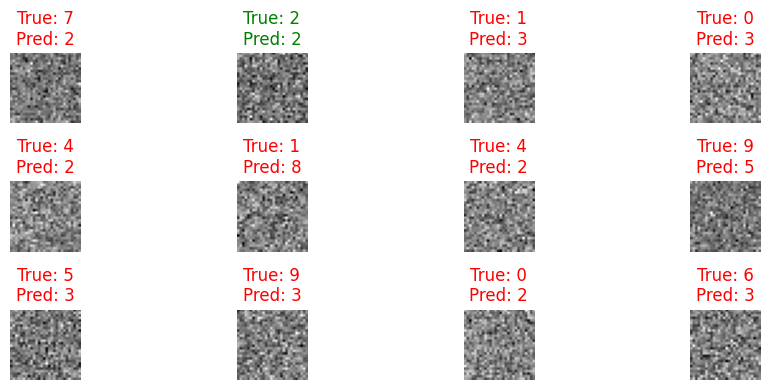

In [54]:
noisy_images = torch.randn_like(images)

noisy_images, y = noisy_images.float().to(device), y.long().to(device)

with torch.no_grad():
    logits = model(noisy_images)
    _, preds = torch.max(logits, 1)

show_images(
    noisy_images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12]
)

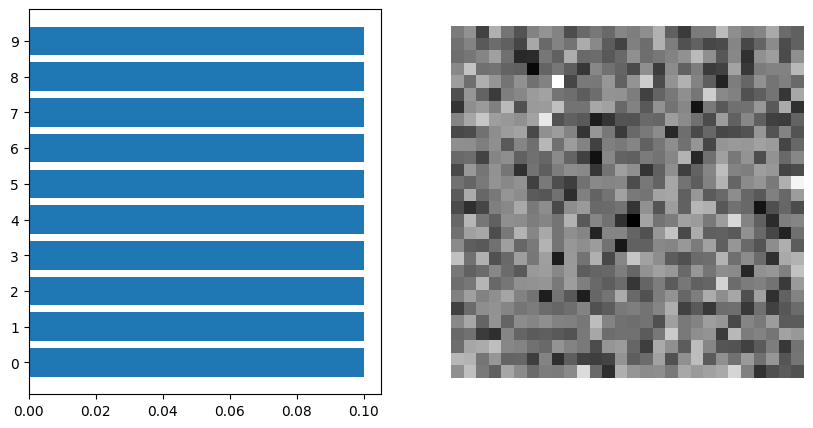

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
evidence = F.softplus(logits[0])
alpha = evidence + 1
probs = alpha / torch.sum(alpha)
axs[0].barh(range(len(probs)), probs)
axs[0].set_yticks(range(len(probs)))

# plot image
axs[1].imshow(noisy_images[0].cpu().numpy().reshape(28, 28), cmap="gray")
axs[1].axis("off");